# SMS Spam Detection pomocu ANN modela

Cilj projekta je klasifikovati SMS poruke kao:

- spam
- ham

Koristimo UCI SMS Spam Collection dataset.

Pipeline projekta:

SMS tekst -> Tokenizer -> sekvence brojeva -> padding -> ANN model -> spam/ham

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

In [ ]:
!wget -q https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip
!unzip -q -o sms+spam+collection.zip

In [ ]:
!ls

readme	     SMSSpamCollection	      sms+spam+collection.zip.1
sample_data  sms+spam+collection.zip


## 2. Učitavanje dataseta

Dataset se nalazi u fajlu `SMSSpamCollection`.

Svaki red ima dva dijela:

- labelu: `ham` ili `spam`
- tekst SMS poruke

Pošto fajl nema nazive kolona, ručno dodajemo kolone `label` i `message`.

In [ ]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.shape

(5572, 2)

In [ ]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


Dataset je nebalansiran, jer ima vise normalnih ham poruka nego spam poruka. Zato accuracy nije jedina dovoljna metrika, nego kasnije gledamo i precision, recall i F1-score.

In [ ]:
df.isnull().sum()

,0
label,0
message,0


Nemamo nedostajucih vrijednosti unutar dataset-a.

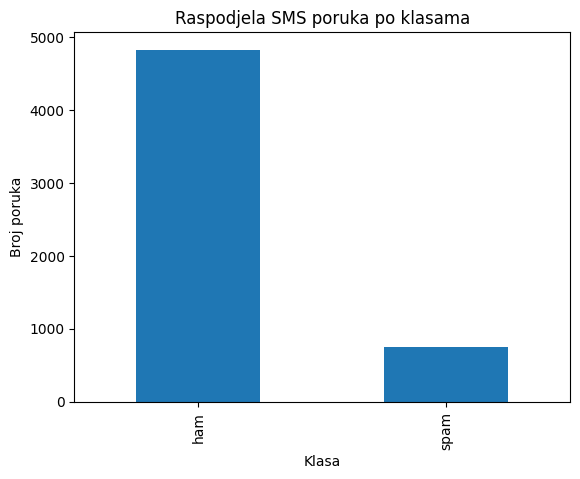

In [ ]:
df["label"].value_counts().plot(kind="bar")

plt.title("Raspodjela SMS poruka po klasama")
plt.xlabel("Klasa")
plt.ylabel("Broj poruka")
plt.show()

## 3. Pretvaranje labela u brojeve

Model ne može direktno raditi sa tekstualnim labelama `ham` i `spam`.

Zato ih pretvaramo u brojeve:

- `ham` -> 0
- `spam` -> 1

Pošto želimo predvidjeti da li je poruka spam, spam označavamo kao pozitivnu klasu `1`.

In [ ]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


Sada odjavamo ulaz i izlaz:
X = tekstovi SMS poruka
y = klase 0/1

In [ ]:
X = df["message"].values
y = df["label_num"].values

In [ ]:
print("Primjer poruke:")
print(X[0])

print("\nLabela:")
print(y[0])

Primjer poruke:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Labela:
0


## 4. Podjela na trening i test skup

Podatke dijelimo na:

- trening skup: koristi se za učenje modela
- test skup: koristi se za konačnu provjeru modela

Koristimo 80% podataka za trening i 20% za testiranje.

Parametar `stratify=y` čuva približno isti omjer `ham` i `spam` poruka u trening i test skupu.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Broj trening poruka:", len(X_train))
print("Broj test poruka:", len(X_test))

Broj trening poruka: 4457
Broj test poruka: 1115


In [ ]:
print("Omjer klasa u cijelom datasetu:")
print(pd.Series(y).value_counts(normalize=True))

print("\nOmjer klasa u trening skupu:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nOmjer klasa u test skupu:")
print(pd.Series(y_test).value_counts(normalize=True))

Omjer klasa u cijelom datasetu:
0    0.865937
1    0.134063
Name: proportion, dtype: float64

Omjer klasa u trening skupu:
0    0.865829
1    0.134171
Name: proportion, dtype: float64

Omjer klasa u test skupu:
0    0.866368
1    0.133632
Name: proportion, dtype: float64


Dakle, koristenjem stratify podijelu dobija se trening i test skup koji imaju priblizno isti omjer spam i ham poruka kao i originalni dataset.

## 5. Tokenizacija teksta

Neuronska mreža ne može direktno raditi sa tekstom.

Zato koristimo `Tokenizer`, koji svakoj riječi dodjeljuje jedan broj.

Na primjer:

- "free" -> 15
- "call" -> 31
- "now" -> 57

Nakon tokenizacije, svaka SMS poruka postaje sekvenca brojeva.

Tokenizer učimo samo na trening podacima, da ne bi model unaprijed vidio informacije iz test skupa.

In [ ]:
VOCAB_SIZE = 10000
OOV_TOKEN = "<OOV>"

VOCAB_SIZE = maksimalan broj rijeci koje tokenizer čuva

OOV_TOKEN = oznaka za rijeci koje nisu vidjene u trening skupu

In [ ]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

In [ ]:
tokenizer.fit_on_texts(X_train)

In [ ]:
word_index = tokenizer.word_index

print("Broj riječi u riječniku:", len(word_index))
print("Prvih 20 riječi:")
print(list(word_index.items())[:20])

Broj riječi u riječniku: 7934
Prvih 20 riječi:
[('<OOV>', 1), ('i', 2), ('to', 3), ('you', 4), ('a', 5), ('the', 6), ('u', 7), ('and', 8), ('in', 9), ('is', 10), ('my', 11), ('me', 12), ('for', 13), ('your', 14), ('it', 15), ('call', 16), ('of', 17), ('have', 18), ('on', 19), ('2', 20)]


## 6. Pretvaranje teksta u sekvence brojeva

Nakon što je Tokenizer napravio riječnik, svaku SMS poruku pretvaramo u listu brojeva pomoću `texts_to_sequences`.

Na primjer:

"call me now"

može postati:

[31, 18, 57]

In [ ]:
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

In [ ]:
print("Originalna poruka:")
print(X_train[0])

print("\nSekvenca brojeva:")
print(train_sequences[0])

Originalna poruka:
He will, you guys close?

Sekvenca brojeva:
[72, 33, 4, 339, 670]


Sljedeci problem koji treba da se rjesi je taj da su nke SMS poruke kratke dok su neke SMS poruke duge. Neuronska mreza ocekuje da je svaki ulaz iste duzine i iz tog razloga cemo da koristimo padding.

Ako je poruka kraca od zadane duzine, dodaju se nule. Ako je poruka duza od zadane duzine, skracuje se.

In [ ]:
MAX_LENGTH = 50
PADDING_TYPE = "post"
TRUNC_TYPE = "post"

MAX_LENGTH = svaka poruka ce imati 50 brojeva

PADDING_TYPE = "post" znaci da se nule dodaju na kraj

TRUNC_TYPE = "post" znaci da se preduge poruke skracuju sa kraja

In [ ]:
X_train_padded = pad_sequences(
    train_sequences,
    maxlen=MAX_LENGTH,
    padding=PADDING_TYPE,
    truncating=TRUNC_TYPE
)

X_test_padded = pad_sequences(
    test_sequences,
    maxlen=MAX_LENGTH,
    padding=PADDING_TYPE,
    truncating=TRUNC_TYPE
)

In [ ]:
print("Oblik trening podataka:", X_train_padded.shape)
print("Oblik test podataka:", X_test_padded.shape)

Oblik trening podataka: (4457, 50)
Oblik test podataka: (1115, 50)


Dakle imamo sada 4459 trening poruka , 1115 test poruka i svaka poruka ima 50 brojeva.

In [ ]:
print("Originalna sekvenca:")
print(train_sequences[0])

print("\nSekvenca nakon paddinga:")
print(X_train_padded[0])

Originalna sekvenca:
[72, 33, 4, 339, 670]

Sekvenca nakon paddinga:
[ 72  33   4 339 670   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


## 8. Kreiranje ANN modela

Nakon tokenizacije i paddinga, tekstualne poruke su pretvorene u numeričke sekvence.

Sada pravimo ANN model koji se sastoji od:

1. `Embedding` sloja
2. `GlobalAveragePooling1D` sloja
3. `Dense` sloja
4. `Dropout` sloja
5. izlaznog `Dense` sloja sa sigmoid aktivacijom

Pošto imamo binarnu klasifikaciju, izlaz je jedna vrijednost između 0 i 1.

Vrijednost blizu 0 znači `ham`, a vrijednost blizu 1 znači `spam`.

In [ ]:
EMBEDDING_DIM = 16

Ovo znaci da ce svaka rijec biti predstavljena vektorom od 16 brojeva. Na primjer rijec "free" nece biti samo jedan broj nego vektor [0.12, -0.44, 0.31, ..., 0.88].

In [ ]:
model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    GlobalAveragePooling1D(),

    Dense(24, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

## 9. Kompajliranje modela

Prije treniranja moramo definisati:

- loss funkciju
- optimizer
- metrike

Koristimo `binary_crossentropy` jer imamo binarnu klasifikaciju.

Koristimo `adam` optimizer jer je standardan i efikasan za neuronske mreže.

Kao osnovnu metriku pratimo `accuracy`.

In [ ]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 10. Treniranje modela

Model treniramo na trening podacima.

Koristimo dio trening podataka za validaciju.

Validacija služi da vidimo kako se model ponaša na podacima koje ne koristi direktno za učenje.

In [ ]:
EPOCHS = 15
BATCH_SIZE = 32

In [ ]:
history = model.fit(
    X_train_padded,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8715 - loss: 0.3768 - val_accuracy: 0.8430 - val_loss: 0.3583
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8715 - loss: 0.3163 - val_accuracy: 0.8430 - val_loss: 0.3386
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8715 - loss: 0.2805 - val_accuracy: 0.8430 - val_loss: 0.2829
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8920 - loss: 0.2054 - val_accuracy: 0.9182 - val_loss: 0.1985
Epoch 5/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9576 - loss: 0.1424 - val_accuracy: 0.9596 - val_loss: 0.1439
Epoch 6/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9759 - loss: 0.1026 - val_accuracy: 0.9664 - val_loss: 0.1090
Epoch 7/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9806 - loss: 0.0786 - val_accuracy: 0.9753 - val_loss: 0.0882
Epoch 8/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9868 - loss: 0.0618 - val_accuracy: 0

## 11. Grafovi treniranja

Nakon treniranja prikazujemo accuracy i loss kroz epohe.

Ovi grafovi nam pomažu da vidimo da li model stvarno uči i da li dolazi do overfittinga.

Ako trening accuracy raste, a validation accuracy stagnira ili pada, to može značiti da model previše pamti trening podatke.

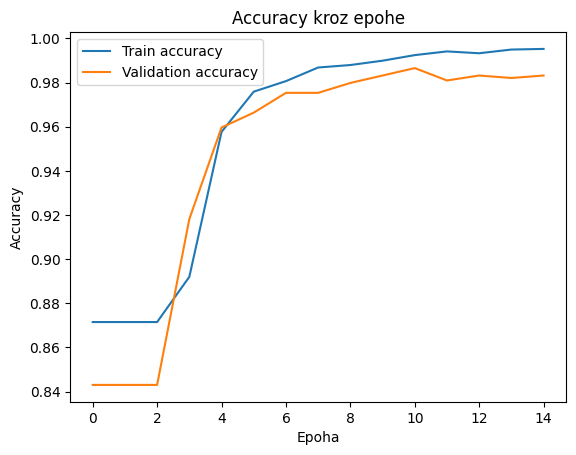

In [ ]:
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Accuracy kroz epohe")
plt.xlabel("Epoha")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

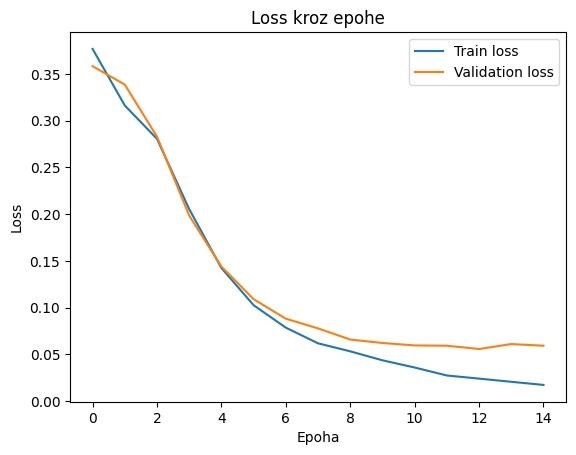

In [ ]:
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Loss kroz epohe")
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 12. Evaluacija na test skupu

Test skup nije korišten tokom treniranja modela.

Zato ga koristimo za konačnu provjeru performansi modela.

Na test skupu računamo loss i accuracy.

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.053452424705028534
Test accuracy: 0.9847533702850342


## 13. Predikcije na test skupu

Model kao izlaz daje vjerovatnoću da je poruka spam.

Pošto koristimo sigmoid aktivaciju, izlaz je broj između 0 i 1.

Koristimo prag 0.5:

- ako je vrijednost >= 0.5, poruka je spam
- ako je vrijednost < 0.5, poruka je ham

In [ ]:
y_prob = model.predict(X_test_padded)

y_pred = (y_prob >= 0.5).astype(int).flatten()

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
for i in range(10):
    print("Poruka:", X_test[i])
    print("Stvarna klasa:", "spam" if y_test[i] == 1 else "ham")
    print("Predikcija:", "spam" if y_pred[i] == 1 else "ham")
    print("Vjerovatnoća spam klase:", round(float(y_prob[i][0]), 4))
    print("-" * 80)

Poruka: No need to buy lunch for me.. I eat maggi mee..
Stvarna klasa: ham
Predikcija: ham
Vjerovatnoća spam klase: 0.0005
--------------------------------------------------------------------------------
Poruka: Ok im not sure what time i finish tomorrow but i wanna spend the evening with you cos that would be vewy vewy lubly! Love me xxx
Stvarna klasa: ham
Predikcija: ham
Vjerovatnoća spam klase: 0.0
--------------------------------------------------------------------------------
Poruka: Waiting in e car 4 my mum lor. U leh? Reach home already?
Stvarna klasa: ham
Predikcija: ham
Vjerovatnoća spam klase: 0.0001
--------------------------------------------------------------------------------
Poruka: You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327
Stvarna klasa: spam
Predikcija: spam
Vjerovatnoća spam klase: 0.9867
--------------------------------------------------------------------------------
Poruka: If you r @ home then come down within 5 min
Stvarna klasa: ham
P

Accuracy nije dovoljna metrika zato sto dataset nije balansiran. Ako ima mnogo vise ham poruka, model moze imati visoku accuracy cak i ako slabije prepoznaje spam, zato gledamo i precision, recall i F1-score.

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["ham", "spam"]
))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



Kod spam detekcije, zelimo da model ima dobar recall za spam klasu, jer zelimo da sto manje spam poruka prodje kao normalna ham poruka.

## 15. Confusion matrix

Confusion matrix prikazuje tačne i pogrešne klasifikacije modela.

Za naš problem imamo dvije klase:

- ham
- spam

Posebno su bitne greške gdje model stvarnu spam poruku klasifikuje kao ham.

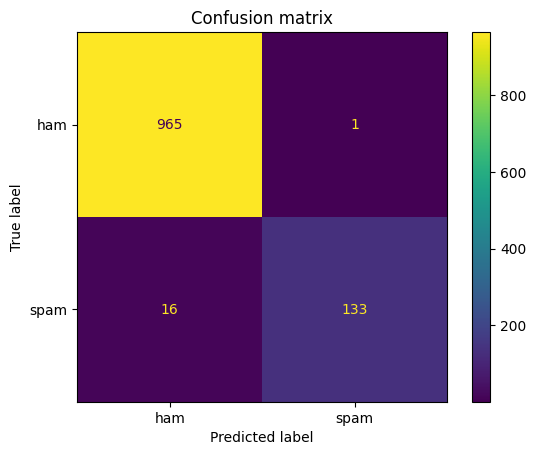

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

disp.plot()
plt.title("Confusion matrix")
plt.show()

## 16. Funkcija za klasifikaciju nove SMS poruke

Nakon treniranja i evaluacije modela, pravimo funkciju koja prima tekst nove SMS poruke i klasifikuje je kao `spam` ili `ham`.

Nova poruka mora proći kroz isti preprocessing kao i trening podaci:

1. tokenizacija
2. padding
3. predikcija modela

Model vraća vjerovatnoću da je poruka spam.

Ako je vjerovatnoća veća ili jednaka 0.5, poruku klasifikujemo kao spam.

Ako je vjerovatnoća manja od 0.5, poruku klasifikujemo kao ham.

In [ ]:
def klasifikuj_sms(tekst):
    sekvenca = tokenizer.texts_to_sequences([tekst])

    padded = pad_sequences(
        sekvenca,
        maxlen=MAX_LENGTH,
        padding=PADDING_TYPE,
        truncating=TRUNC_TYPE
    )

    vjerovatnoca = model.predict(padded, verbose=0)[0][0]

    if vjerovatnoca >= 0.5:
        klasa = "spam"
    else:
        klasa = "ham"

    print("Poruka:", tekst)
    print("Vjerovatnoća spam klase:", round(float(vjerovatnoca), 4))
    print("Predikcija:", klasa)

    return klasa

## 17. Testiranje modela na novim porukama

Sada testiramo model na nekoliko ručno napisanih SMS poruka.

Prva i treća poruka imaju tipične spam riječi kao što su `won`, `free`, `ticket`, `urgent`, `prize` i `call`.

Druga poruka je obična normalna poruka.

In [ ]:
klasifikuj_sms("Congratulations! You won a free ticket. Call now.")

Poruka: Congratulations! You won a free ticket. Call now.
Vjerovatnoća spam klase: 0.632
Predikcija: spam


'spam'

In [ ]:
klasifikuj_sms("Hey, are we still meeting today?")

Poruka: Hey, are we still meeting today?
Vjerovatnoća spam klase: 0.0003
Predikcija: ham


'ham'

In [ ]:
klasifikuj_sms("URGENT! You have won a prize. Text WIN to 80085 now.")

Poruka: URGENT! You have won a prize. Text WIN to 80085 now.
Vjerovatnoća spam klase: 0.9524
Predikcija: spam


'spam'

In [ ]:
klasifikuj_sms("Can you call me when you get home?")

Poruka: Can you call me when you get home?
Vjerovatnoća spam klase: 0.0009
Predikcija: ham


'ham'

In [ ]:
moja_poruka = input("Unesi SMS poruku: ")

klasifikuj_sms(moja_poruka)

Unesi SMS poruku: Congrats! You have won! Text me to claim your prize!
Poruka: Congrats! You have won! Text me to claim your prize!
Vjerovatnoća spam klase: 0.796
Predikcija: spam


'spam'